In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/emotions-dataset-for-nlp/val.txt
/kaggle/input/emotions-dataset-for-nlp/test.txt
/kaggle/input/emotions-dataset-for-nlp/train.txt
/kaggle/input/go-emotions-google-emotions-dataset/go_emotions_dataset.csv


In [2]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the Dataset
# Standard Kaggle paths for "Emotions dataset for NLP"
train_df = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/train.txt', sep=';', header=None, names=['text', 'label'])
val_df = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/val.txt', sep=';', header=None, names=['text', 'label'])

# 2. Define the SVM Pipeline
# We use LinearSVC for its efficiency with text data
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('clf', CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced')))
])

# 3. Train the Model
print("Training SVM Model...")
model_pipeline.fit(train_df['text'], train_df['label'])

# 4. Evaluate the Model
# We predict on the validation set to see the report
predictions = model_pipeline.predict(val_df['text'])

print("\n--- MODEL EVALUATION REPORT ---")
print(f"Overall Accuracy: {accuracy_score(val_df['label'], predictions):.2%}")
print("\nDetailed Performance per Emotion:")
# This shows Precision, Recall, and F1-Score for every category
print(classification_report(val_df['label'], predictions))

# 5. Save the final model
joblib.dump(model_pipeline, 'emotion_svm_prod.joblib')
print("\nModel saved as 'emotion_svm_prod.joblib'. You can now download it.")

Training SVM Model...

--- MODEL EVALUATION REPORT ---
Overall Accuracy: 90.85%

Detailed Performance per Emotion:
              precision    recall  f1-score   support

       anger       0.92      0.91      0.92       275
        fear       0.88      0.83      0.85       212
         joy       0.93      0.93      0.93       704
        love       0.83      0.87      0.85       178
     sadness       0.92      0.94      0.93       550
    surprise       0.81      0.80      0.81        81

    accuracy                           0.91      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.91      0.91      0.91      2000


Model saved as 'emotion_svm_prod.joblib'. You can now download it.


Training final XGBoost model...

--- FINAL 7-EMOTION CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         joy       0.60      0.68      0.64      8805
       anger       0.18      0.28      0.22      2289
        fear       0.41      0.45      0.43       904
     sadness       0.47      0.44      0.45      3745
    surprise       0.36      0.36      0.36      5790
     disgust       0.28      0.36      0.31      1074
     neutral       0.30      0.98      0.46     11185

   micro avg       0.36      0.65      0.46     33792
   macro avg       0.37      0.51      0.41     33792
weighted avg       0.40      0.65      0.47     33792
 samples avg       0.38      0.50      0.42     33792



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Success! Model saved and confusion_matrix.png generated.


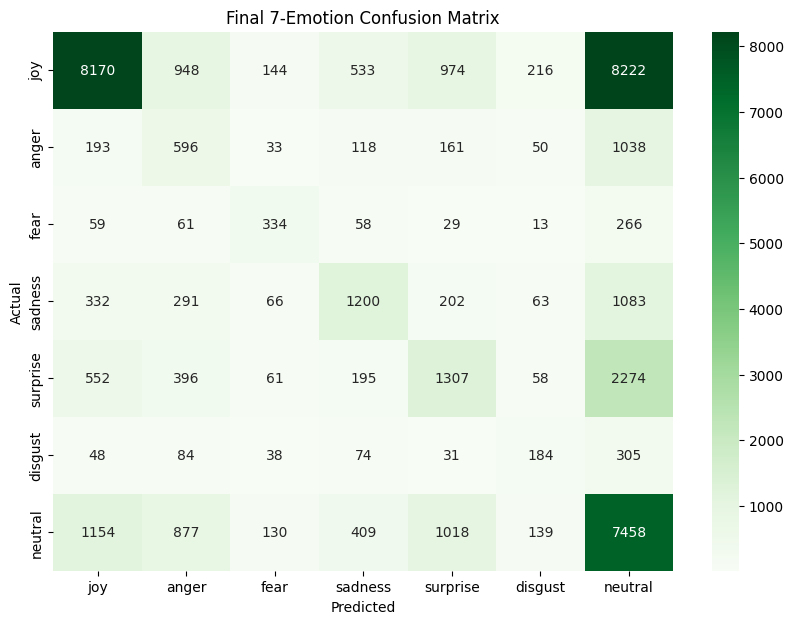

In [3]:
import pandas as pd
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv('/kaggle/input/go-emotions-google-emotions-dataset/go_emotions_dataset.csv')
emotion_columns = list(df.columns[9:]) 

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df[emotion_columns], test_size=0.2, random_state=42
)

# 2. The Final Pipeline
# We use scale_pos_weight=4 to tell XGBoost to focus 4x more on 
# detected emotions vs. the 'None/Neutral' background.
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10000)),
    ('clf', OneVsRestClassifier(XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=7,
        scale_pos_weight=4,  # Fixes the imbalance without the fit() error
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )))
])

# 3. Train (Clean fit without keyword errors)
print("Training final XGBoost model...")
model_pipeline.fit(X_train, y_train)

# 4. Mapping Logic (28 -> 7)
ekman_mapping = {
    "joy": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "anger": ["anger", "annoyance", "disapproval"],
    "fear": ["fear", "nervousness"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
    "disgust": ["disgust"],
    "neutral": ["neutral"]
}

def map_to_7(matrix, labels, mapping):
    new_matrix = np.zeros((matrix.shape[0], len(mapping)))
    for i, (target, sources) in enumerate(mapping.items()):
        indices = [labels.index(s) for s in sources if s in labels]
        new_matrix[:, i] = np.max(matrix[:, indices], axis=1)
    return new_matrix

# 5. Evaluation with Threshold Tuning
probs = model_pipeline.predict_proba(X_test)
y_pred_28 = (probs >= 0.3).astype(int) # Lower threshold to catch more emotions

y_test_7 = map_to_7(y_test.values, emotion_columns, ekman_mapping)
y_pred_7 = map_to_7(y_pred_28, emotion_columns, ekman_mapping)

print("\n--- FINAL 7-EMOTION CLASSIFICATION REPORT ---")
target_names = list(ekman_mapping.keys())
print(classification_report(y_test_7, y_pred_7, target_names=target_names))

# 6. Save Confusion Matrix for GitHub README
cm = confusion_matrix(y_test_7.argmax(axis=1), y_pred_7.argmax(axis=1))
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Greens')
plt.title('Final 7-Emotion Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')

# 7. Save Model Data
model_data = {
    'pipeline': model_pipeline,
    'labels': emotion_columns,
    'ekman_mapping': ekman_mapping
}
joblib.dump(model_data, 'emotion_model_final.joblib')
print("\nSuccess! Model saved and confusion_matrix.png generated.")